In [56]:
%pip install --upgrade pip
%pip install pytorch
%pip install torchvision
%pip install opencv-python
%pip install matplotlib
%pip install scikit-image
%pip install numpy
%pip install tqdm
%pip install tensorboard

Note: you may need to restart the kernel to use updated packages.
  Using cached pytorch-1.0.2.tar.gz (689 bytes)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for pytorch (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [37 lines of output]
      Traceback (most recent call last):
        File "/Users/7n100489/Library/CloudStorage/OneDrive-BankofAyudhyaPublicCompanyLimited/Desktop/Workspace/github/kmitl-image-processing/.venv/lib/python3.13/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "/Users/7n100489/Library/CloudStorage/OneDrive-BankofAyudhyaPublicCompanyLimited/Desktop/Workspace/github/kmitl-image-processing/.venv/lib/python3.13/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
         

# **Lab 4.2 NN MLP and CNN**

In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,Subset
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

Complete the `load_data()` function that loads the image using `ImageFolder()` with the specific `transforms.compose()` provided below.
`load_data()` will return `DataLoader()` and print the information about the Dataset.
This function must load only a pair of classes from the entire dataset.
Please ensure that the final image is in grayscale and has a size of 28x28.

`transforms.Compose()` :
- `transforms.Resize(32)`
- `transforms.ToTensor()`
- `transforms.Pad()`
- `transforms.RandomRotation(45),`
- `transforms.CenterCrop(28)`

Resource : [`transforms.Compose()`](https://pytorch.org/vision/main/generated/torchvision.transforms.Compose.html#compose), [`torchvision.transforms v1`](<https://pytorch.org/vision/stable/transforms.html#v1-api-reference:~:text=custom)%20tv_tensor%20type.-,V1%20API%20Reference,-Geometry>)

In [58]:
def load_data(path, class_names):
    ### START CODE HERE ###
    transform = transforms.Compose(
        [
            transforms.Resize((32, 32)),
            transforms.ToTensor(),
            transforms.Pad(10),
            transforms.RandomRotation(45),
            transforms.CenterCrop(28),
            transforms.Grayscale(num_output_channels=1),
        ]
    )

    dataset = ImageFolder(path, transform=transform)

    # filter dataset by class names
    filtered_indices = [
        i
        for i, (_, label) in enumerate(dataset)
        if dataset.classes[label] in class_names
    ]
    filtered_dataset = Subset(dataset, filtered_indices)

    train_size = int(0.8 * len(filtered_dataset))
    test_size = len(filtered_dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(
        filtered_dataset, [train_size, test_size]
    )

    # print("📃Train Dataset:")
    # class_counts = [
    #     sum(1 for _, label in train_dataset if dataset.classes[label] == cls)
    #     for cls in class_names
    # ]
    # for cls, count in zip(class_names, class_counts):
    #     print(f"\tNumber of images in class {cls}: {count}")

    # print(f"\tNumber of training samples: {len(train_dataset)}")

    # print("📃Test Dataset:")
    # class_counts = [
    #     sum(1 for _, label in test_dataset if dataset.classes[label] == cls)
    #     for cls in class_names
    # ]
    # for cls, count in zip(class_names, class_counts):
    #     print(f"\tNumber of images in class {cls}: {count}")

    # print(f"\tNumber of training samples: {len(test_dataset)}")

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    ### END CODE HERE ###

    return train_loader, test_loader

Use your `load_data()` function to load the dataset in the cell below. Then, display the image from the first batch.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

```
📃Train Dataset:
	Number of images in class 0: 313
	Number of images in class 1: 308
	Number of training samples: 621

📃Test Dataset:
	Number of images in class 0: 75
	Number of images in class 1: 81
	Number of testing samples: 156
```


![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/03.png?raw=true)

</details>

In [59]:
def show_first_batch_image(data_loader):
    images, labels = next(iter(data_loader))

    images = images[:16]

    fig, axs = plt.subplots(4, 4, figsize=(6, 6))
    for i in range(len(images)):
        axs[i // 4, i % 4].imshow(images[i].squeeze(0), cmap='gray')
        axs[i // 4, i % 4].set_title(f"Label: {labels[i].item()}")
        axs[i // 4, i % 4].axis("off")
    plt.tight_layout()
    plt.show()

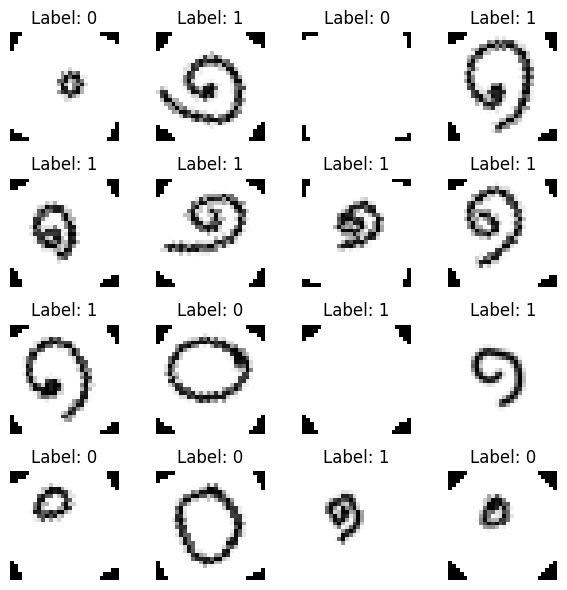

In [60]:
### START CODE HERE ###
class_names = ["0", "1"]
train_loader, test_loader = load_data(
    "./thai-handwriting-number.appspot.com", class_names
)

show_first_batch_image(train_loader)
### END CODE HERE ###

**Create Models**
1. **NN (Neural Network)**:
- **Input**: 28x28 grayscale images (1 channel)
- **Architecture**: Single fully connected layer with sigmoid activation
- **Output**: Single neuron output with sigmoid activation
- **Description**: This is a simple feedforward neural network with a single fully connected layer. It takes input images, flattens them, passes through a fully connected layer, and applies sigmoid activation to produce the output.

2. **MLP (Multi-Layer Perceptron)**:
- **Input**: 28x28 grayscale images (1 channel)
- **Architecture**: Two fully connected layers with sigmoid activations
- **Output**: Single neuron output with sigmoid activation
- **Description**: This is a multi-layer perceptron with two fully connected layers. After flattening the input images, it passes through the first fully connected layer with sigmoid activation, followed by the second fully connected layer with sigmoid activation, producing the output.

3. **CNN (Convolutional Neural Network)**:
- **Input**: 28x28 grayscale images (1 channel)
- **Architecture**: Two convolutional layers with ReLU activations, followed by two fully connected layers with ReLU activations
- **Output**: Single neuron output with sigmoid activation
- **Description**: This is a convolutional neural network with two convolutional layers followed by two fully connected layers. It applies convolutional operations with ReLU activations, followed by flattening the output and passing through fully connected layers with ReLU activations. Finally, it produces a single neuron output with sigmoid activation.


Every model should have a `get_features()` method that returns the result from all layers.

In [61]:
### START CODE HERE ###
class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.fc = nn.Linear(28 * 28, 1)
        self.activation = nn.Sigmoid()

    def get_features(self, x):
        x = x.view(x.size(0), -1)
        out = self.fc(x)
        return self.activation(out)

    def forward(self, x):
        return self.get_features(x)


class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 1)
        self.activation = nn.Sigmoid()

    def get_features(self, x):
        x = x.view(x.size(0), -1)  # Flatten the input
        x_out = self.activation(self.fc1(x))
        out = self.fc2(x_out)
        return self.activation(out)

    def forward(self, x):
        return self.get_features(x)


class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def get_features(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        out = self.fc2(x)
        return self.sigmoid(out)

    def forward(self, x):
        return self.get_features(x)


### END CODE HERE ###

Complete the function below. This function will be used to display the feature map from the models at every epoch on TensorBoard.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output that will be display on TensorBoard</b>
</font>
</summary>

- The output should resemble this, but not be identical
- `NN()`<br>
![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/04.png?raw=true)
- `MLP()`<br>
![image-2.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/05.png?raw=true)
- `CNN()`<br>
![image-3.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/06.png?raw=true)
</details>

In [62]:
def show_featuremaps(features):
    feats = features.detach().cpu().numpy().squeeze()
    batch_size = feats.shape[0] if len(feats.shape) > 0 else 1

    fig, axs = plt.subplots(figsize=(10, 10))
    axs.bar(np.arange(batch_size), feats, color="blue")
    axs.set_xlabel("Batch Index")
    axs.set_ylabel("Feature Value")
    axs.set_ylim(0, 1)
    axs.set_title("Feature Map Values")

    return fig

TensorBoard 101

Complete the `train()` function in the cell below. This function should evaluate the model at every epoch, log the training loss/accuracy, test loss/accuracy, and display the feature map from all layers of the model at every epoch on TensorBoard. Additionally, it should save the model at the last epoch.

Resource : [PyTorch Training loop](<https://pytorch.org/tutorials/beginner/introyt/trainingyt.html#:~:text=%3D0.9)-,The%20Training%20Loop,-Below%2C%20we%20have>), [TensorBoard](https://pytorch.org/docs/stable/tensorboard.html)

<details>
<summary>
<font size="3" color="orange">
<b>Expected output that will be display on TensorBoard</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/07.png?raw=true)

![image-2.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/08.png?raw=true)
</details>

In [63]:
def train(
    class_names,
    model,
    opt,
    loss_fn,
    train_loader,
    test_loader,
    epochs=10,
    writer=None,
    checkpoint_path=None,
    device="cpu",
):
    ### START CODE HERE ###

    model.to(device)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}"):
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)

            opt.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels.float().clamp(0, 1))
            loss.backward()
            opt.step()

            train_loss += loss.item() * inputs.size(0)
            predictions = (outputs > 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        avg_loss = train_loss / len(train_loader.dataset)
        train_accuracy = correct / total

        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(inputs)
                loss = loss_fn(outputs, labels.float().clamp(0, 1))
                test_loss += loss.item() * inputs.size(0)

                predictions = (outputs > 0.5).float()
                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        avg_test_loss = test_loss / len(test_loader.dataset)
        test_accuracy = correct / total

        if writer:
            writer.add_scalar("Loss/train", avg_loss, epoch)
            writer.add_scalar("Loss/test", avg_test_loss, epoch)
            writer.add_scalar("Accuracy/train", train_accuracy, epoch)
            writer.add_scalar("Accuracy/test", test_accuracy, epoch)

            try:
                if hasattr(model, "get_features"):
                    features = model.get_features(inputs)
                    fig = show_featuremaps(features)
                    writer.add_figure("Feature Maps", fig, epoch)
                    plt.close(fig)
            except Exception as e:
                print(f"Error in feature visualization: {e}")

        print(
            f"Epoch {epoch + 1}/{epochs}, Train Loss: {avg_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}"
        )

    if checkpoint_path:
        os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Model saved to {checkpoint_path}")
    ### END CODE HERE ###

Use your `train()` function to train all types of models with all combinations of numbers that you've obtained.

In [65]:
### START CODE HERE ###
from itertools import combinations

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = {"nn": NN(), "mlp": MLP(), "cnn": CNN()}


pair_digit = list(combinations(range(10), 2))

for class1, class2 in pair_digit:
    print(f"Training model for pair: {class1} vs {class2}")

    class_names = [str(class1), str(class2)]
    train_loader, test_loader = load_data(
        "./thai-handwriting-number.appspot.com", class_names
    )

    for name, model_instance in models.items():
        print(f"Training {name} model...")
        opt = torch.optim.Adam(model_instance.parameters(), lr=0.001)
        writer = SummaryWriter(log_dir=f"./runs/{name}_{class1}_vs_{class2}")
        model = model_instance.to(device)

        train(
            class_names,
            model,
            opt,
            loss_fn=nn.BCELoss(),
            train_loader=train_loader,
            test_loader=test_loader,
            epochs=10,
            writer=writer,
            checkpoint_path=f"./checkpoints/{name}_{class1}_vs_{class2}.pth",
            device=device,
        )

        writer.close()
### END CODE HERE ###

Training model for pair: 0 vs 1
Training nn model...


Epoch 1/10: 100%|██████████| 20/20 [00:00<00:00, 33.26it/s]


Epoch 1/10, Train Loss: 0.6996, Train Accuracy: 0.5153, Test Loss: 0.6804, Test Accuracy: 0.5321


Epoch 2/10: 100%|██████████| 20/20 [00:00<00:00, 35.72it/s]


Epoch 2/10, Train Loss: 0.6655, Train Accuracy: 0.6248, Test Loss: 0.6728, Test Accuracy: 0.5641


...

Epoch 8/10, Train Loss: 0.0000, Train Accuracy: 0.0000, Test Loss: 0.0000, Test Accuracy: 0.0000


Epoch 9/10: 100%|██████████| 20/20 [00:00<00:00, 25.32it/s]


Epoch 9/10, Train Loss: 0.0000, Train Accuracy: 0.0000, Test Loss: 0.0000, Test Accuracy: 0.0000


Epoch 10/10: 100%|██████████| 20/20 [00:00<00:00, 24.71it/s]


Epoch 10/10, Train Loss: 0.0000, Train Accuracy: 0.0000, Test Loss: 0.0000, Test Accuracy: 0.0000
Model saved to ./checkpoints/cnn_8_vs_9.pth


Try to load the weights into the model and the confusion matrix for each model with every combination of numbers that you've obtained, as shown in the expected output.


<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical
This is just an example of NN. You should have three models: NN, MLP, and CNN, with one model per plot.

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/09.png?raw=true)

</details>


==== Evaluating all pairs for model: nn ====
Evaluating pair: 0 vs 1
Evaluating pair: 0 vs 2
Evaluating pair: 0 vs 3
Evaluating pair: 0 vs 4
Evaluating pair: 0 vs 5
Evaluating pair: 0 vs 6
Evaluating pair: 0 vs 7
Evaluating pair: 0 vs 8
Evaluating pair: 0 vs 9
Evaluating pair: 1 vs 2
Evaluating pair: 1 vs 3
Evaluating pair: 1 vs 4
Evaluating pair: 1 vs 5
Evaluating pair: 1 vs 6
Evaluating pair: 1 vs 7
Evaluating pair: 1 vs 8
Evaluating pair: 1 vs 9
Evaluating pair: 2 vs 3
Evaluating pair: 2 vs 4
Evaluating pair: 2 vs 5
Evaluating pair: 2 vs 6
Evaluating pair: 2 vs 7
Evaluating pair: 2 vs 8
Evaluating pair: 2 vs 9
Evaluating pair: 3 vs 4
Evaluating pair: 3 vs 5
Evaluating pair: 3 vs 6
Evaluating pair: 3 vs 7
Evaluating pair: 3 vs 8
Evaluating pair: 3 vs 9
Evaluating pair: 4 vs 5
Evaluating pair: 4 vs 6
Evaluating pair: 4 vs 7
Evaluating pair: 4 vs 8
Evaluating pair: 4 vs 9
Evaluating pair: 5 vs 6
Evaluating pair: 5 vs 7
Evaluating pair: 5 vs 8
Evaluating pair: 5 vs 9
Evaluating pair: 6

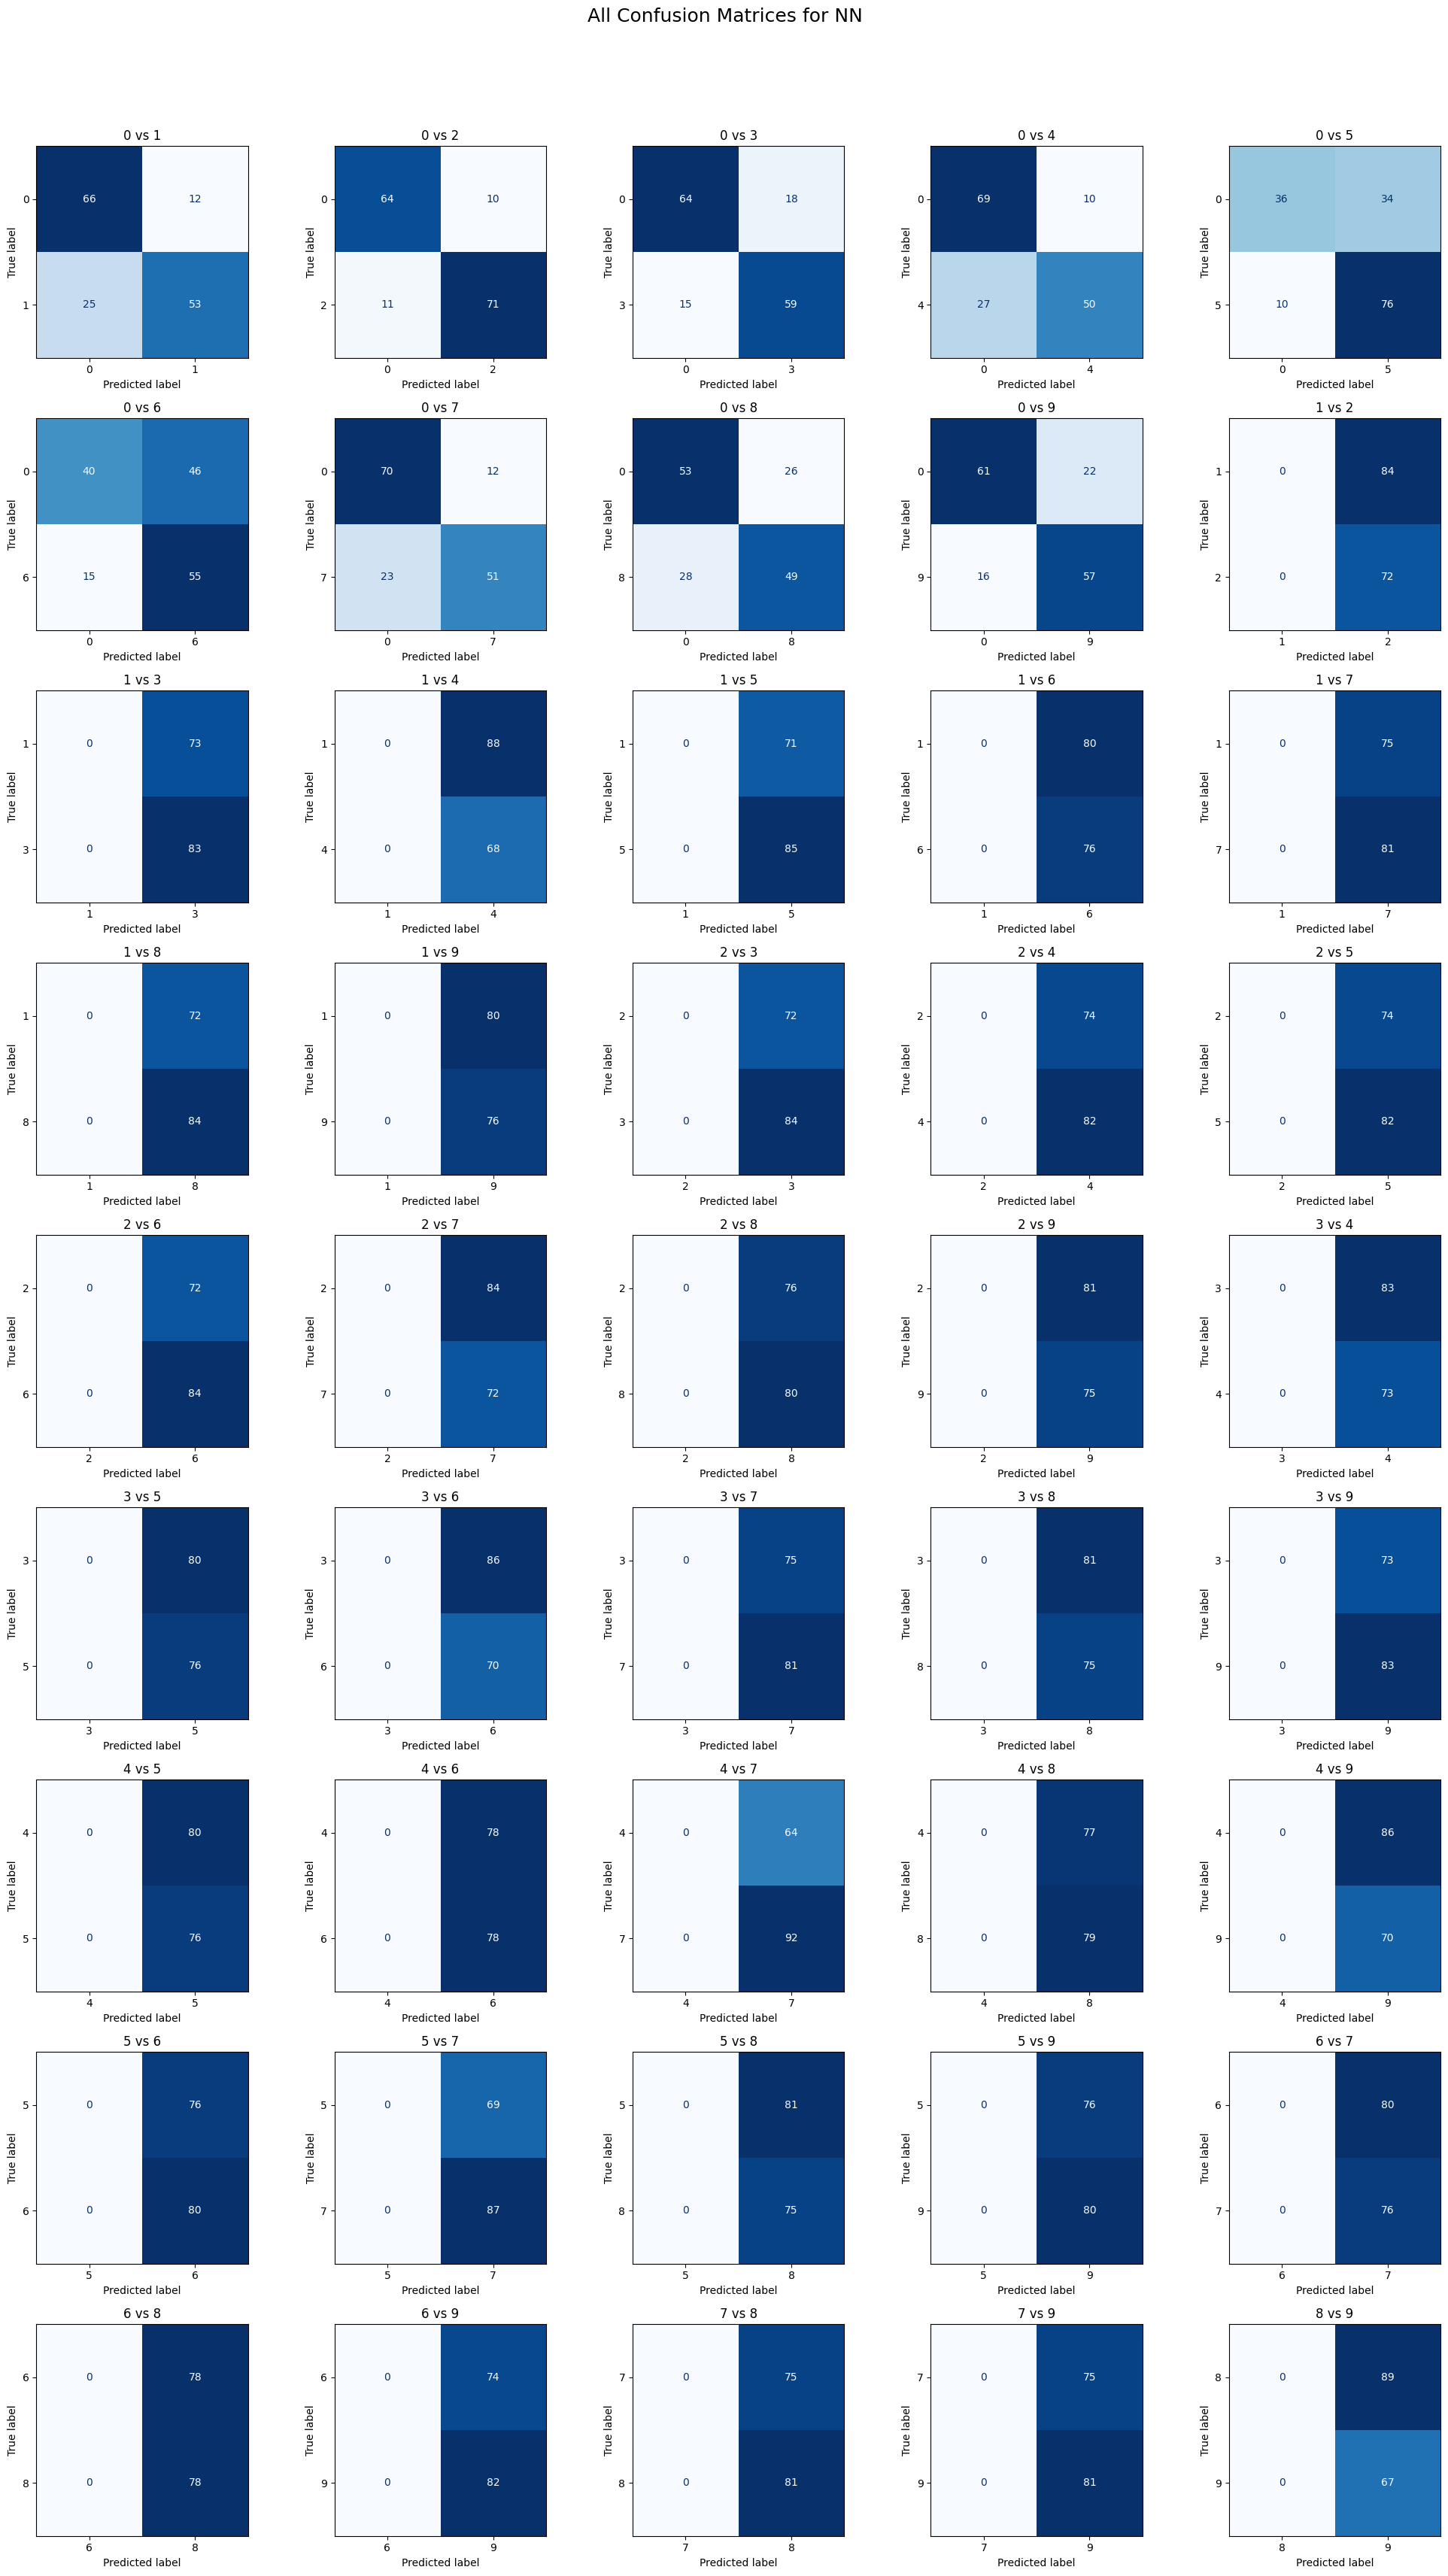


==== Evaluating all pairs for model: mlp ====
Evaluating pair: 0 vs 1
Evaluating pair: 0 vs 2
Evaluating pair: 0 vs 3
Evaluating pair: 0 vs 4
Evaluating pair: 0 vs 5
Evaluating pair: 0 vs 6
Evaluating pair: 0 vs 7
Evaluating pair: 0 vs 8
Evaluating pair: 0 vs 9
Evaluating pair: 1 vs 2
Evaluating pair: 1 vs 3
Evaluating pair: 1 vs 4
Evaluating pair: 1 vs 5
Evaluating pair: 1 vs 6
Evaluating pair: 1 vs 7
Evaluating pair: 1 vs 8
Evaluating pair: 1 vs 9
Evaluating pair: 2 vs 3
Evaluating pair: 2 vs 4
Evaluating pair: 2 vs 5
Evaluating pair: 2 vs 6
Evaluating pair: 2 vs 7
Evaluating pair: 2 vs 8
Evaluating pair: 2 vs 9
Evaluating pair: 3 vs 4
Evaluating pair: 3 vs 5
Evaluating pair: 3 vs 6
Evaluating pair: 3 vs 7
Evaluating pair: 3 vs 8
Evaluating pair: 3 vs 9
Evaluating pair: 4 vs 5
Evaluating pair: 4 vs 6
Evaluating pair: 4 vs 7
Evaluating pair: 4 vs 8
Evaluating pair: 4 vs 9
Evaluating pair: 5 vs 6
Evaluating pair: 5 vs 7
Evaluating pair: 5 vs 8
Evaluating pair: 5 vs 9
Evaluating pair: 

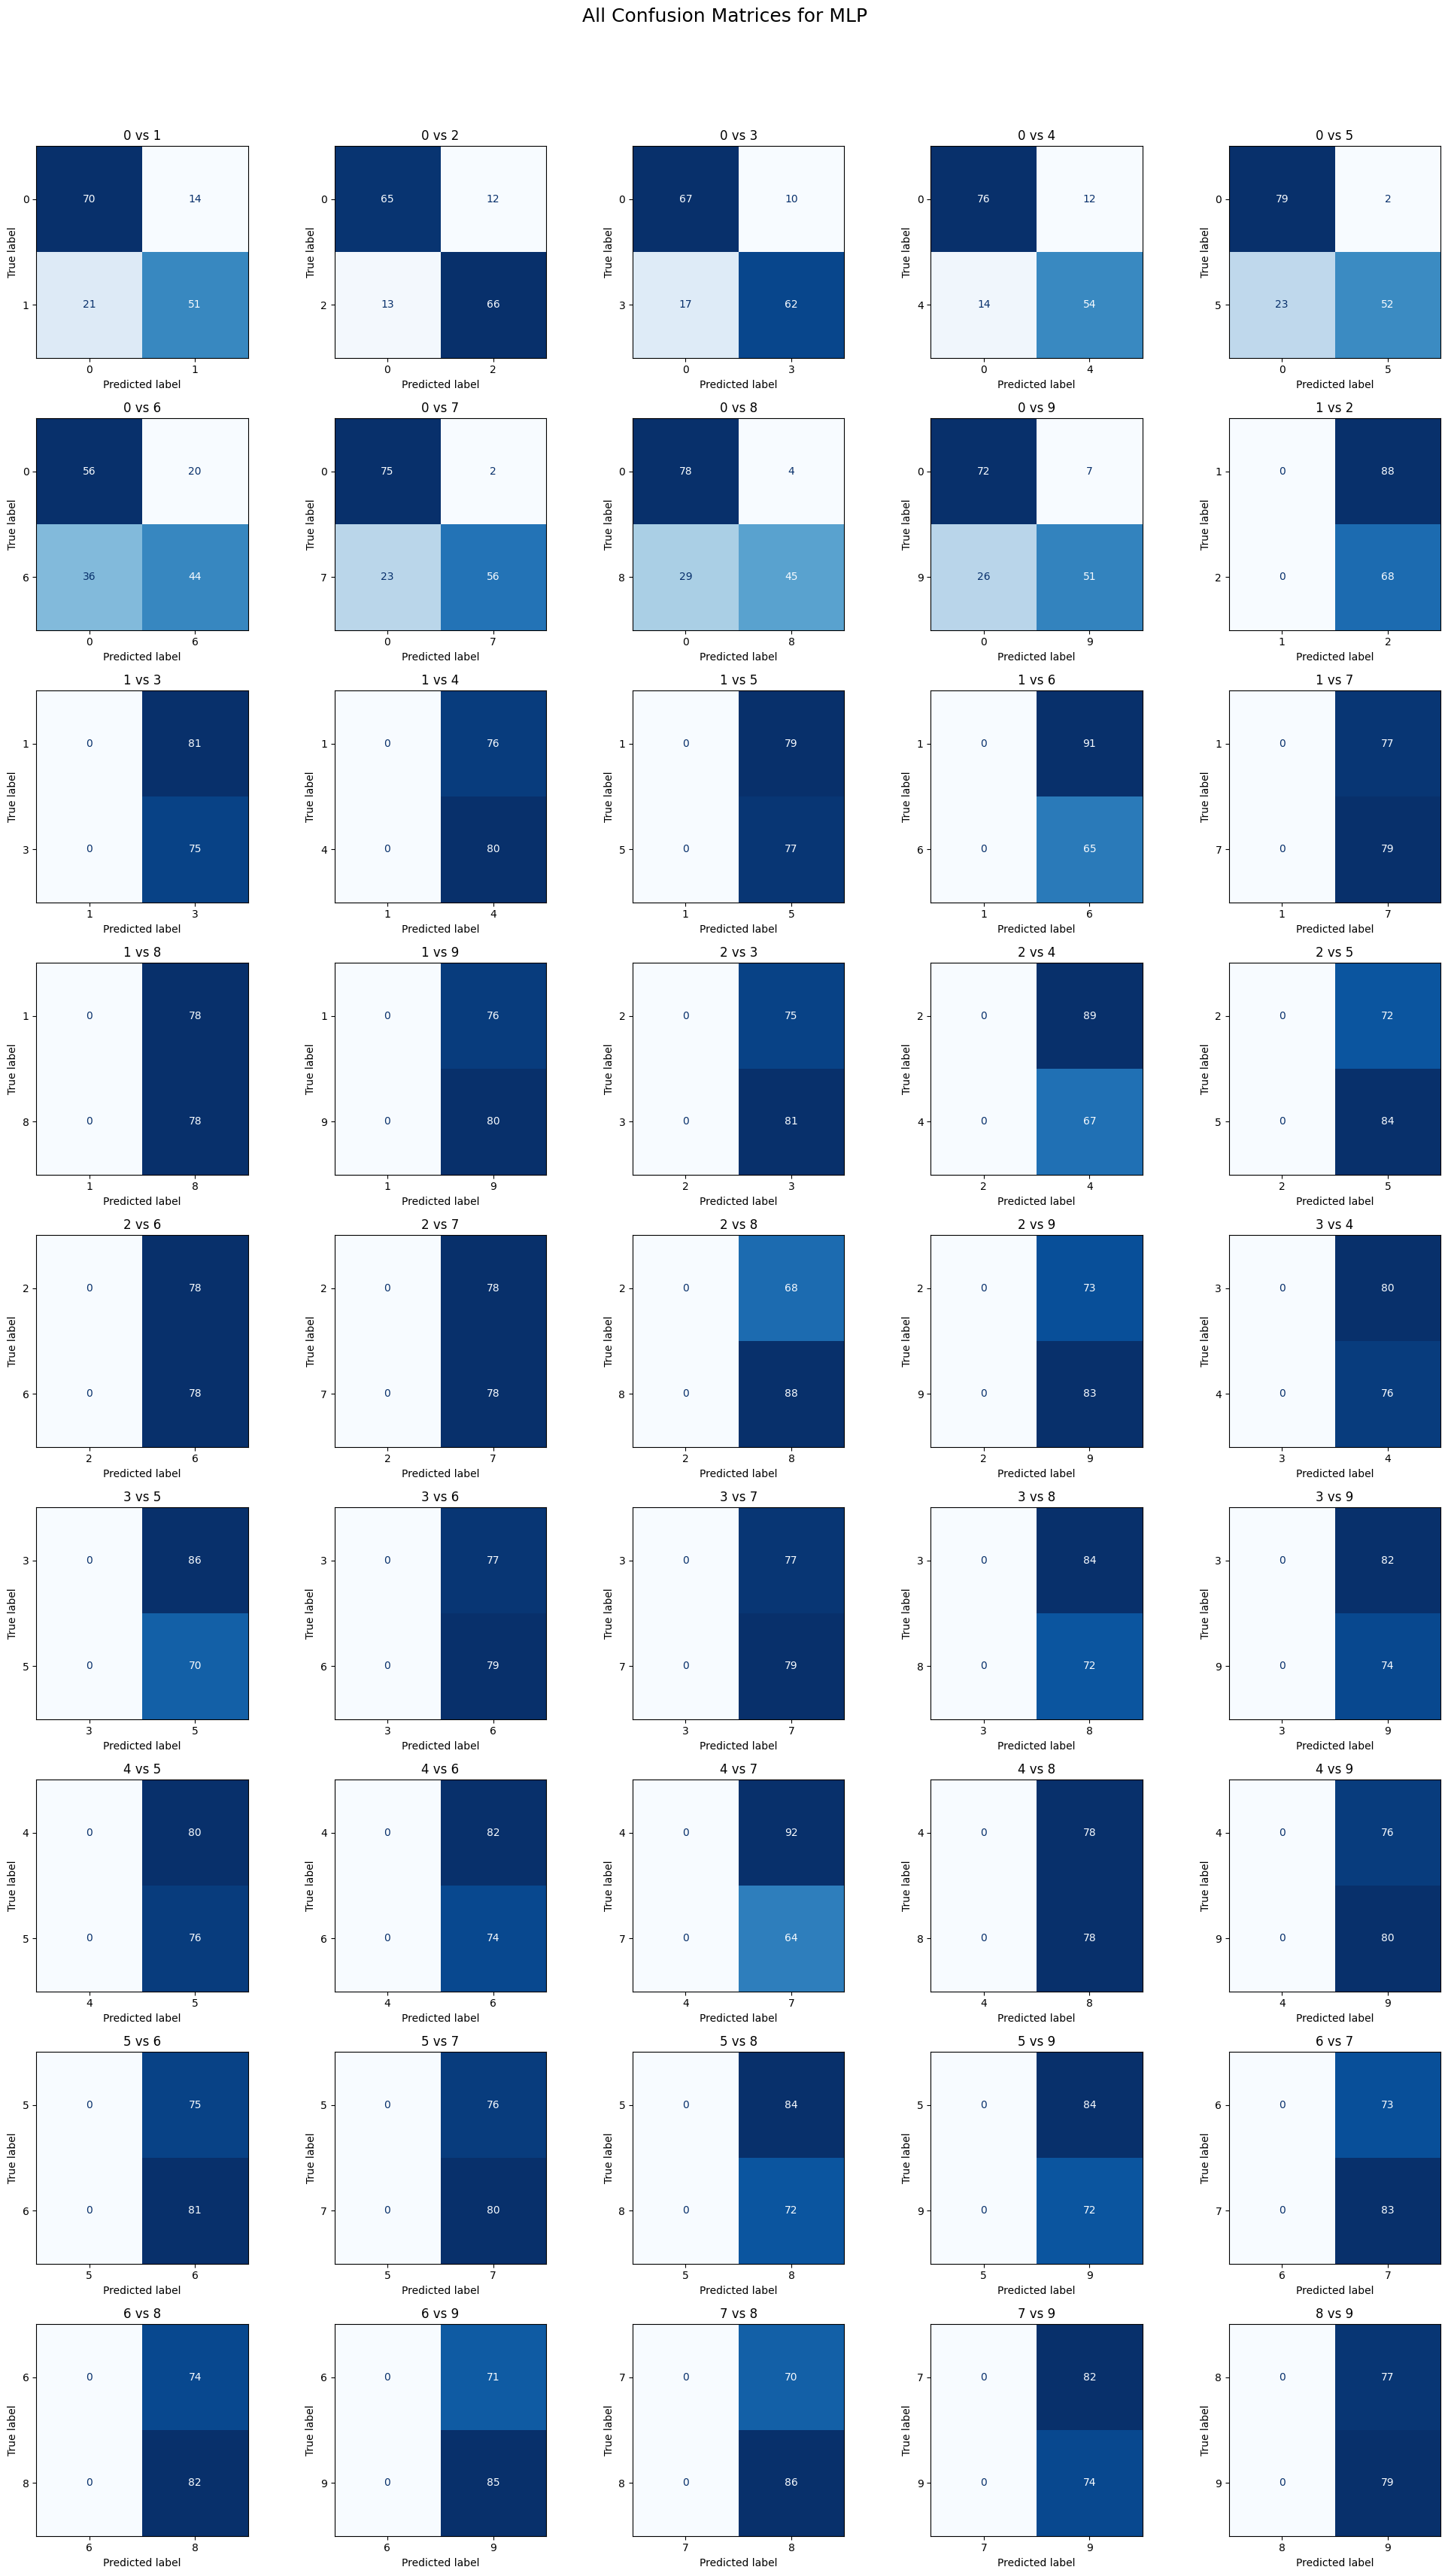


==== Evaluating all pairs for model: cnn ====
Evaluating pair: 0 vs 1
Evaluating pair: 0 vs 2
Evaluating pair: 0 vs 3
Evaluating pair: 0 vs 4
Evaluating pair: 0 vs 5
Evaluating pair: 0 vs 6
Evaluating pair: 0 vs 7
Evaluating pair: 0 vs 8
Evaluating pair: 0 vs 9
Evaluating pair: 1 vs 2
Evaluating pair: 1 vs 3
Evaluating pair: 1 vs 4
Evaluating pair: 1 vs 5
Evaluating pair: 1 vs 6
Evaluating pair: 1 vs 7
Evaluating pair: 1 vs 8
Evaluating pair: 1 vs 9
Evaluating pair: 2 vs 3
Evaluating pair: 2 vs 4
Evaluating pair: 2 vs 5
Evaluating pair: 2 vs 6
Evaluating pair: 2 vs 7
Evaluating pair: 2 vs 8
Evaluating pair: 2 vs 9
Evaluating pair: 3 vs 4
Evaluating pair: 3 vs 5
Evaluating pair: 3 vs 6
Evaluating pair: 3 vs 7
Evaluating pair: 3 vs 8
Evaluating pair: 3 vs 9
Evaluating pair: 4 vs 5
Evaluating pair: 4 vs 6
Evaluating pair: 4 vs 7
Evaluating pair: 4 vs 8
Evaluating pair: 4 vs 9
Evaluating pair: 5 vs 6
Evaluating pair: 5 vs 7
Evaluating pair: 5 vs 8
Evaluating pair: 5 vs 9
Evaluating pair: 

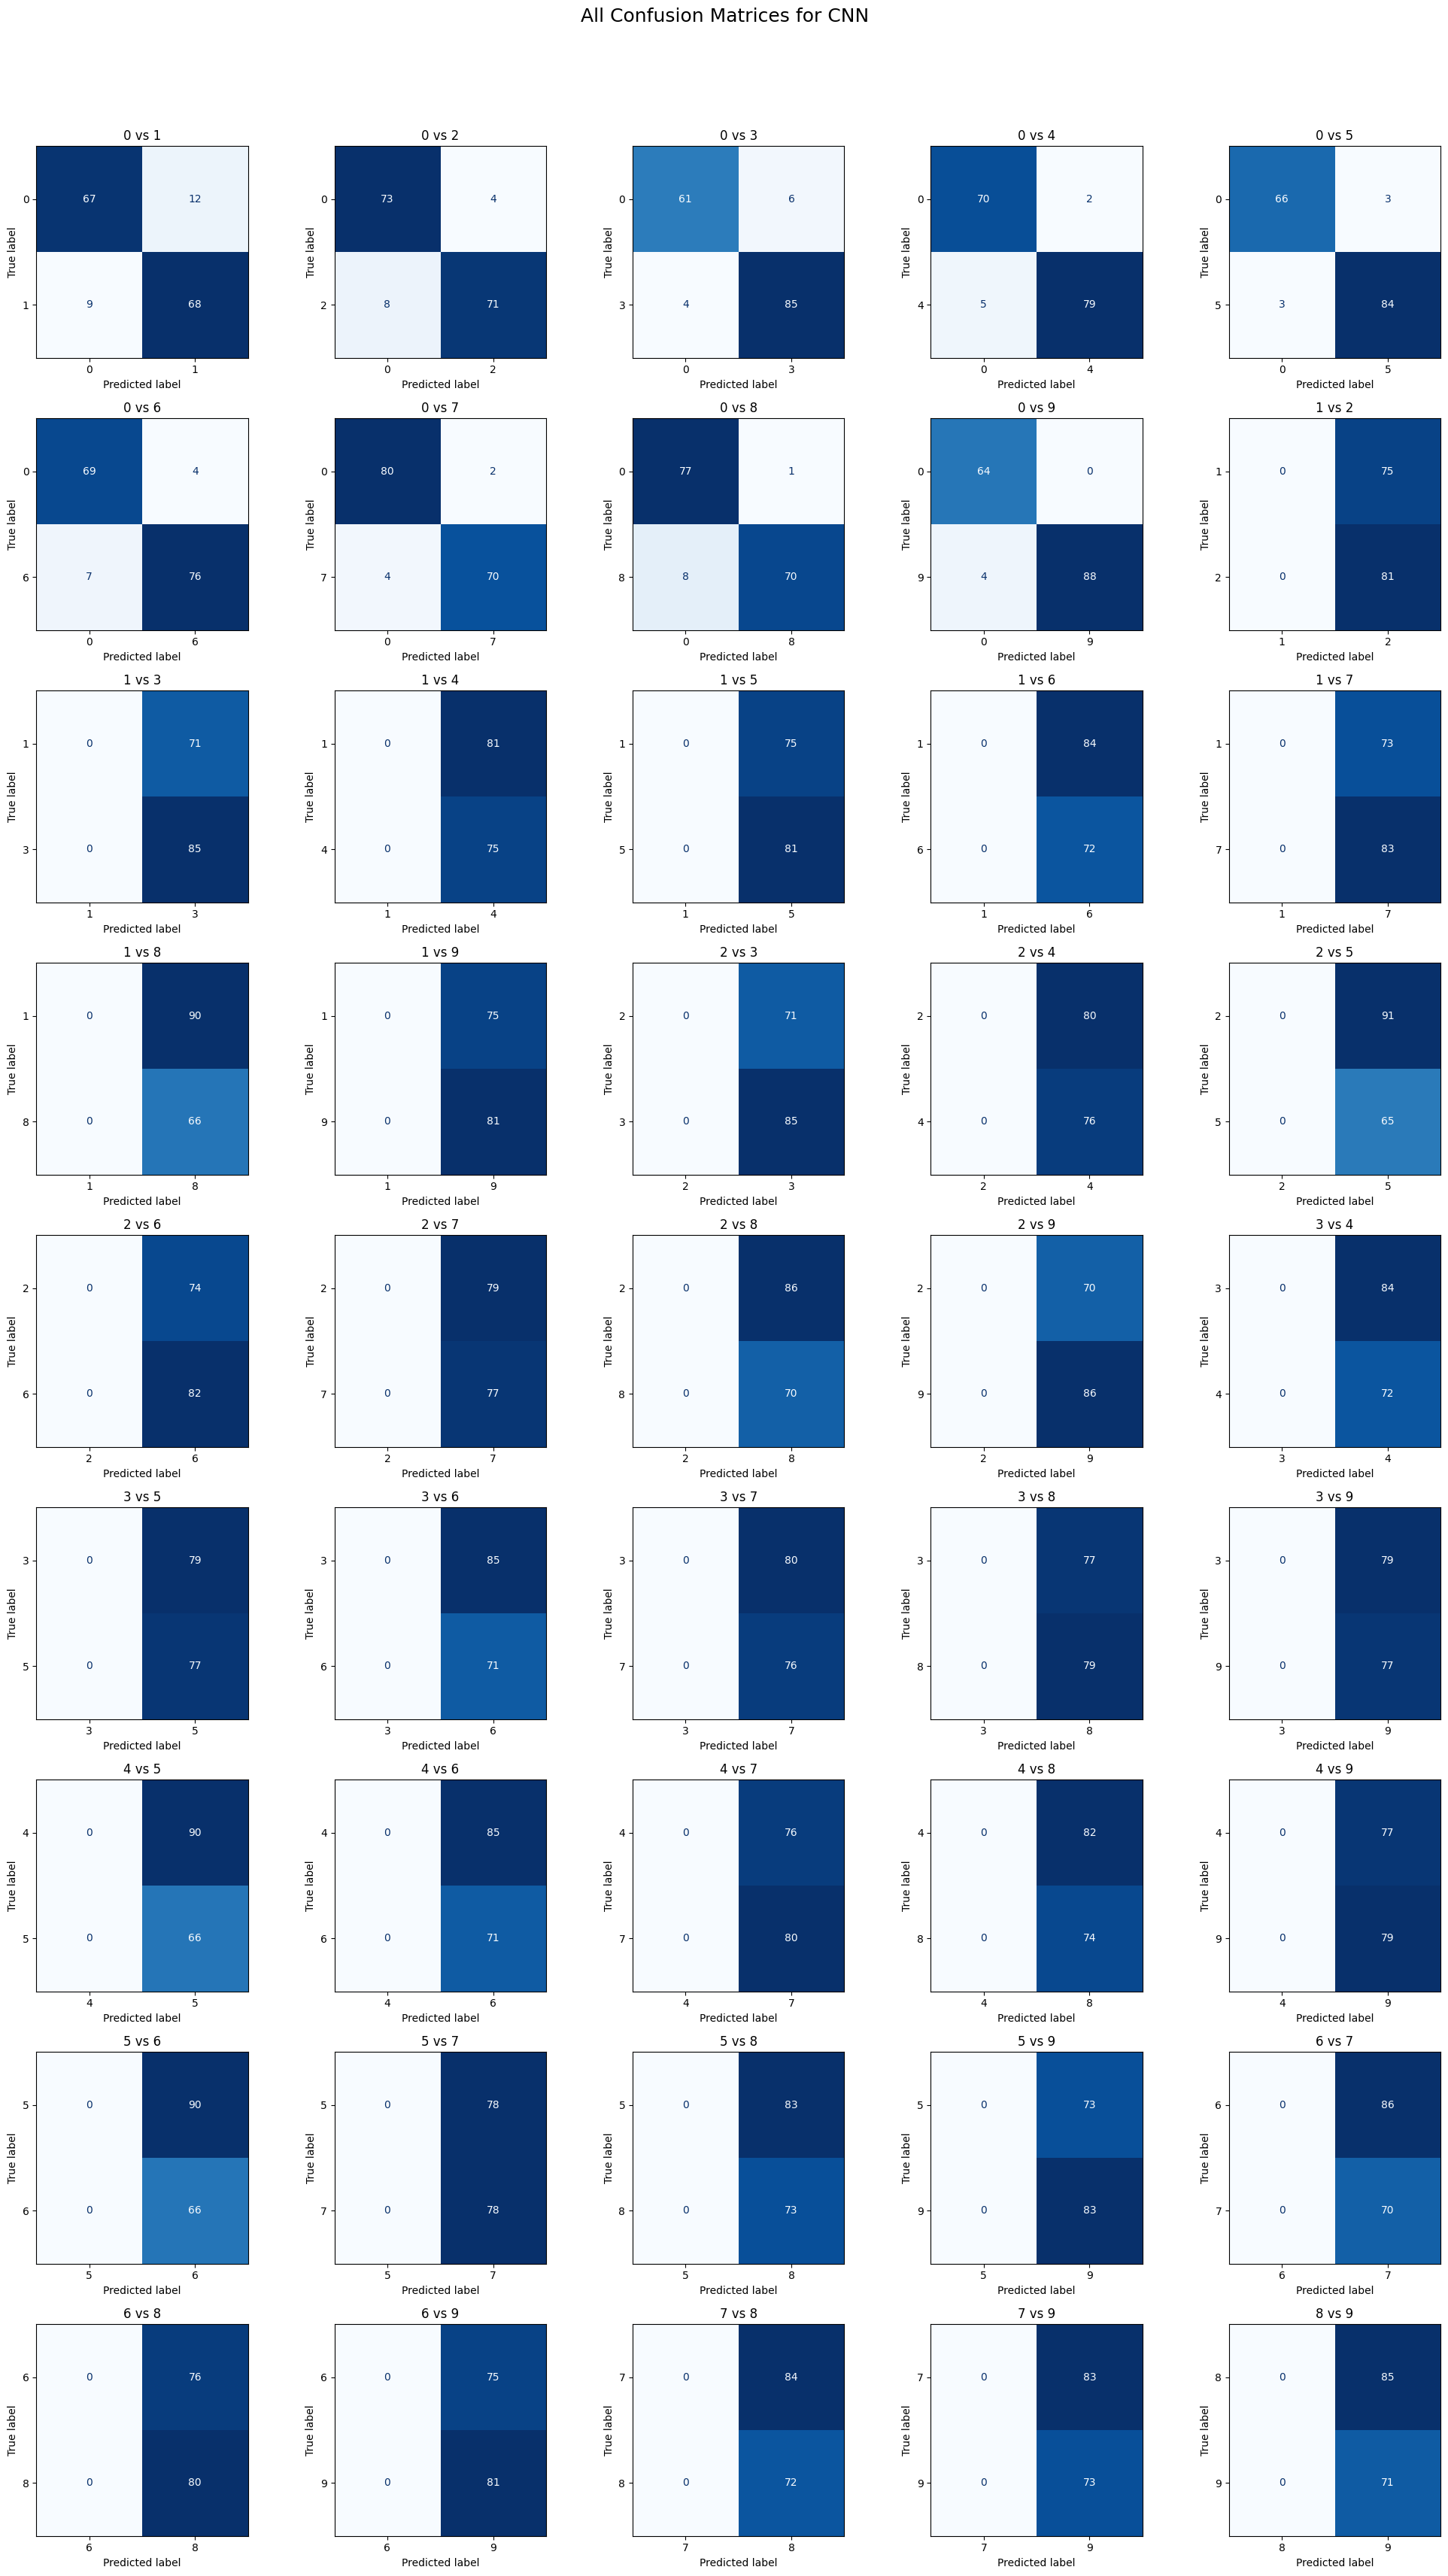

In [66]:
### START CODE HERE ###
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import math

cols = 5
num_pairs = len(pair_digit)
rows = math.ceil(num_pairs / cols)

for name, model_instance in models.items():
    print(f"\n==== Evaluating all pairs for model: {name} ====")

    fig, axs = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axs = axs.flatten()

    for idx, (class1, class2) in enumerate(pair_digit):
        print(f"Evaluating pair: {class1} vs {class2}")
        class_names = [str(class1), str(class2)]
        train_loader, test_loader = load_data(
            "./thai-handwriting-number.appspot.com", class_names
        )

        model = model_instance.to(device)
        checkpoint_path = f"./checkpoints/{name}_{class1}_vs_{class2}.pth"
        if not os.path.exists(checkpoint_path):
            print(f"Checkpoint {checkpoint_path} not found. Skipping.")
            axs[idx].axis("off")
            continue

        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.eval()

        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(inputs)
                predictions = (outputs > 0.5).float()
                all_predictions.extend(predictions.cpu().numpy().flatten())
                all_labels.extend(labels.cpu().numpy().flatten())

        label_map = {str(class1): 0, str(class2): 1}
        all_labels_mapped = [label_map.get(str(l), -1) for l in all_labels]
        all_predictions_mapped = [int(p) for p in all_predictions]

        filtered = [
            (l, p)
            for l, p in zip(all_labels_mapped, all_predictions_mapped)
            if l in [0, 1]
        ]

        if not filtered:
            print(f"No valid predictions for pair {class1} vs {class2}")
            axs[idx].axis("off")
            continue

        y_true, y_pred = zip(*filtered)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=axs[idx], cmap=plt.cm.Blues, colorbar=False)
        axs[idx].set_title(f"{class1} vs {class2}")


    for ax in axs[num_pairs:]:
        ax.axis("off")

    fig.suptitle(f"All Confusion Matrices for {name.upper()}", fontsize=18)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


### END CODE HERE ###

Questions
1. How does the performance of different models vary across different pairs of numbers in our dataset?
2. Can you identify the number pairs where the Neural Network model performs best and worst? Explain why the NN model is able/unable to classify these specific pairs based on the visualization of feature maps of each node in each layer.
3. Analyze and compare how MLP and CNN models perform on the dataset compared to the Neural Network model.  Identify scenarios where MLP and CNN outperform or underperform the NN. Explain the reasons behind these performance differences. Consider factors like the underlying structure of the data and the specific strengths of each model architecture.
4. According to your observations from questions 1-3, propose specific strategies to improve the performance of each model (NN, MLP, CNN) on this dataset. Consider factors such as data preprocessing, data augmentation, or potential changes to the model architecture itself. Justify your suggestions based on the strengths and limitations identified in the previous questions.
